Fluency–Faithfulness Correlation Analysis (Downsampled)

- Checks how BGE filtering affects the dataset and how COMET QE relates to classifier-based fluency.
- Reports raw, length-split Spearman and Partial Spearman (length-controlled) correlations, with final summary figures.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LinearRegression

In [2]:
classifierResults = Path("../4_classifiers/translation_original/classifier_results/results_kfolds_downsamped_pos_paragraphs.csv")
comet_score_direct = Path("../5_faithfulness_metric/par3_cometqe_scores_colnames_fixed")
metadataCSV = Path("../metadata/par3_dataset_metadata_final.csv")
bge_threshold = 0.50

SourceToComet_mapping = {
    "gt": "comet_score_gt_para",
    "gemma": "comet_score_gemma_para",
    "translator_1": "comet_score_translator_1_para",
    "translator_2": "comet_score_translator_2_para",
    "translator_3": "comet_score_translator_3_para",
    "translator_4": "comet_score_translator_4_para",
    "translator_5": "comet_score_translator_5_para",
}

SourceToBGE_mapping = {
    "gt": "sim_score_gt_para_bge",
    "gemma": "sim_score_gemma_para_bge",
    "translator_1": "sim_score_translator_1_para_bge",
    "translator_2": "sim_score_translator_2_para_bge",
    "translator_3": "sim_score_translator_3_para_bge",
    "translator_4": "sim_score_translator_4_para_bge",
    "translator_5": "sim_score_translator_5_para_bge",
}

lengthBins = [19, 30, 40, 60, 100, np.inf]
binLabels = ["20-30", "31-40", "41-60", "61-100", "100+"]
translatorHumanSources = [s for s in SourceToComet_mapping if s.startswith("translator_")]

translationSourceLabels = {
    "gt": "Google Translate",
    "gemma": "TranslateGemma",
    "human_translation": "Human Translators (pooled)",
}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Georgia", "DejaVu Serif"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e5e0",
    "grid.linewidth": 0.7,
    "axes.axisbelow": True,
    "figure.facecolor": "#fafaf8",
    "axes.facecolor": "#ffffff",
})

In [3]:
def get_matching_value(row, mapping):
    col = mapping.get(row["para_source"])
    return row[col] if col in row.index else np.nan


def spearman_row(df, label):
    sub = df[["fluency", "comet_score"]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) < 5:
        return None
    r, p = stats.spearmanr(sub["fluency"], sub["comet_score"])
    return {"subset": label, "n": len(sub), "spearman_r": r, "p_value": p}


def partial_spearman_pg(df, x_col="fluency", y_col="comet_score", control_col="paragraph_len"):
    sub = df[[x_col, y_col, control_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) < 10:
        return np.nan, np.nan, len(sub)
    result = pg.partial_corr(data=sub, x=x_col, y=y_col, covar=control_col, method="spearman")
    return result["r"].iloc[0], result["p_val"].iloc[0], len(sub)


def sig_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def assign_group(src):
    if src.startswith("translator_"):
        return "human"
    if src in {"gt", "gemma"}:
        return src
    return None

In [4]:
clf_df = pd.read_csv(classifierResults)
clf_df["book_id"] = clf_df["book_id"].astype(str)
clf_df["paragraph_id"] = clf_df["paragraph_id"].astype(str)
clf_df = clf_df[clf_df["translation"] == 1].copy()

comet_parts = []
needed_books = set(clf_df["book_id"])

for path in sorted(comet_score_direct.glob("*.csv")):
    df = pd.read_csv(path)
    if "Book_id" in df.columns:
        df = df.rename(columns={"Book_id": "book_id"})
    df["book_id"] = df["book_id"].astype(str)
    df["paragraph_id"] = df["paragraph_id"].astype(str)
    if not set(df["book_id"]).intersection(needed_books):
        continue
    keep = ["book_id", "paragraph_id"]
    keep += [c for c in df.columns if c.startswith("comet_score_")]
    keep += [c for c in df.columns if c.endswith("_bge")]
    comet_parts.append(df[[c for c in keep if c in df.columns]])

comet_df = pd.concat(comet_parts, ignore_index=True)
merged = clf_df.merge(comet_df, on=["book_id", "paragraph_id"], how="left")
merged["comet_score"] = merged.apply(lambda row: get_matching_value(row, SourceToComet_mapping), axis=1)
merged["bge_sim"] = merged.apply(lambda row: get_matching_value(row, SourceToBGE_mapping), axis=1)

print(f"Classifier rows: {len(clf_df):,}")
print(f"Merged rows: {len(merged):,}")
print(f"Rows with COMET: {merged['comet_score'].notna().sum():,}")
print(f"Rows with BGE: {merged['bge_sim'].notna().sum():,}")

Classifier rows: 130,486
Merged rows: 130,486
Rows with COMET: 130,486
Rows with BGE: 130,486


In [5]:
analysis_ready = merged.dropna(subset=["comet_score", "logreg_prob", "bge_sim"]).copy()
valid = analysis_ready[analysis_ready["bge_sim"] >= bge_threshold].copy()
valid["fluency"] = 1 - valid["logreg_prob"]

removed = len(analysis_ready) - len(valid)
print(f"Rows before BGE threshold: {len(analysis_ready):,}")
print(f"Rows after BGE threshold:  {len(valid):,}")
print(f"Rows removed:              {removed:,} ({100 * removed / len(analysis_ready):.1f}%)")
print(valid["para_source"].value_counts().to_string())

Rows before BGE threshold: 130,486
Rows after BGE threshold:  127,930
Rows removed:              2,556 (2.0%)
para_source
gemma           30885
translator_2    29825
translator_1    29661
gt              29637
translator_3     6494
translator_4     1157
translator_5      271


In [6]:
overall = spearman_row(valid, "ALL")
print(pd.DataFrame([overall]).to_string(index=False))

subset      n  spearman_r      p_value
   ALL 127930   -0.037399 7.807589e-41


In [7]:
length_split_df = pd.DataFrame([
    spearman_row(valid[valid["paragraph_len"] < 100], "<100 words"),
    spearman_row(valid[valid["paragraph_len"] >= 100], ">=100 words"),
])
print(length_split_df.to_string(index=False))

     subset      n  spearman_r       p_value
 <100 words 108589   -0.085999 2.587342e-177
>=100 words  19341   -0.015147  3.515528e-02


In [8]:
fluency_threshold_df = valid.copy()
fluency_threshold_df["source_group"] = np.where(
    fluency_threshold_df["para_source"].str.startswith("translator_", na=False),
    "human_translation",
    fluency_threshold_df["para_source"],
)

fluency_threshold_df = (
    fluency_threshold_df.groupby("source_group")["fluency"]
    .agg(
        n="count",
        pct_above_0_5=lambda x: 100 * (x > 0.5).mean(),
        pct_below_or_equal_0_5=lambda x: 100 * (x <= 0.5).mean(),
    )
    .reset_index()
)

print(fluency_threshold_df.to_string(index=False))

     source_group     n  pct_above_0_5  pct_below_or_equal_0_5
            gemma 30885      15.256597               84.743403
               gt 29637      21.371934               78.628066
human_translation 67408      27.530857               72.469143


In [9]:
length_corrs = []
for col in ["comet_score", "fluency", "bge_sim"]:
    sub = valid.dropna(subset=["paragraph_len", col])
    r, p = stats.spearmanr(sub["paragraph_len"], sub[col])
    length_corrs.append({"pair": f"paragraph_len vs {col}", "n": len(sub), "spearman_r": r, "p_value": p})

print(pd.DataFrame(length_corrs).to_string(index=False))

                        pair      n  spearman_r  p_value
paragraph_len vs comet_score 127930   -0.264082 0.000000
    paragraph_len vs fluency 127930   -0.156531 0.000000
    paragraph_len vs bge_sim 127930    0.007415 0.007994


In [10]:
rho, p, n = partial_spearman_pg(valid)
print(f"Partial Spearman fluency x COMET, controlling for paragraph_len: rho={rho:.4f}, p={p:.6g}, n={n:,}")

Partial Spearman fluency x COMET, controlling for paragraph_len: rho=-0.0827, p=1.02282e-192, n=127,930


In [11]:
valid["length_bin"] = pd.cut(valid["paragraph_len"], bins=lengthBins, labels=binLabels, right=True)
len_records = []

for bin_label in binLabels:
    sub = valid[valid["length_bin"] == bin_label]
    rho, p, n = partial_spearman_pg(sub)
    if not np.isnan(rho):
        len_records.append({"length_bin": bin_label, "para_source": "ALL", "partial_spearman_r": rho, "p_value": p, "n": n})

for src in SourceToComet_mapping:
    for bin_label in binLabels:
        sub = valid[(valid["para_source"] == src) & (valid["length_bin"] == bin_label)]
        rho, p, n = partial_spearman_pg(sub)
        if not np.isnan(rho):
            len_records.append({"length_bin": bin_label, "para_source": src, "partial_spearman_r": rho, "p_value": p, "n": n})

for bin_label in binLabels:
    sub = valid[(valid["para_source"].isin(translatorHumanSources)) & (valid["length_bin"] == bin_label)]
    rho, p, n = partial_spearman_pg(sub)
    if not np.isnan(rho):
        len_records.append({"length_bin": bin_label, "para_source": "human_translation", "partial_spearman_r": rho, "p_value": p, "n": n})

len_df = pd.DataFrame(len_records)
all_df = len_df[len_df["para_source"] == "ALL"].set_index("length_bin").reindex(binLabels)

print("Partial Spearman rho by length bin (ALL sources):")
print(all_df.reset_index()[["length_bin", "n", "partial_spearman_r", "p_value"]].to_string(index=False))

Partial Spearman rho by length bin (ALL sources):
length_bin     n  partial_spearman_r      p_value
     20-30 34945           -0.068441 1.471413e-37
     31-40 21206           -0.101643 8.221252e-50
     41-60 26892           -0.118444 1.315332e-84
    61-100 25914           -0.124931 1.223902e-90
      100+ 18973           -0.111784 8.234921e-54


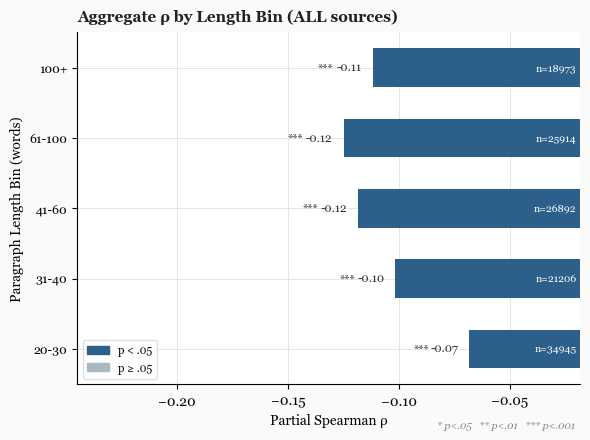

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.patch.set_facecolor("#fafaf8")
x_pos = np.arange(len(binLabels))
bar_vals = list(all_df["partial_spearman_r"].dropna())
bar_colors = ["#2c5f8a" if p < 0.05 else "#aab8c2" for p in all_df["p_value"]]

ax.barh(x_pos, all_df["partial_spearman_r"], color=bar_colors, height=0.55, zorder=3, linewidth=0)

for i, (bin_lbl, row) in enumerate(all_df.iterrows()):
    ax.text(row["partial_spearman_r"] - 0.005, i, f'{row["partial_spearman_r"]:.2f}', ha="right", va="center", fontsize=8.5, color="#333")
    stars = sig_stars(row["p_value"])
    if stars != "ns":
        ax.text(row["partial_spearman_r"] - 0.018, i, stars, ha="right", va="center", fontsize=8, color="#333")
    if row["partial_spearman_r"] < -0.03:
        ax.text(-0.02, i, f'n={int(row["n"])}', ha="right", va="center", fontsize=7.5, color="white")

ax.set_yticks(x_pos)
ax.set_yticklabels(binLabels, fontsize=9)
ax.set_xlim(min(bar_vals) - 0.12, max(bar_vals) + 0.05)
ax.set_xlabel("Partial Spearman ρ", fontsize=10)
ax.set_ylabel("Paragraph Length Bin (words)", fontsize=10)
ax.set_title("Aggregate ρ by Length Bin (ALL sources)", fontsize=11, fontweight="bold", loc="left", pad=8, color="#222")
ax.legend(handles=[mpatches.Patch(color="#2c5f8a", label="p < .05"), mpatches.Patch(color="#aab8c2", label="p ≥ .05")], fontsize=8, loc="lower left", frameon=True, framealpha=0.9, edgecolor="#ddd")
ax.text(0.99, -0.13, "* p<.05   ** p<.01   *** p<.001", transform=ax.transAxes, ha="right", va="bottom", fontsize=7.5, color="#888", style="italic")
plt.tight_layout()
plt.show()

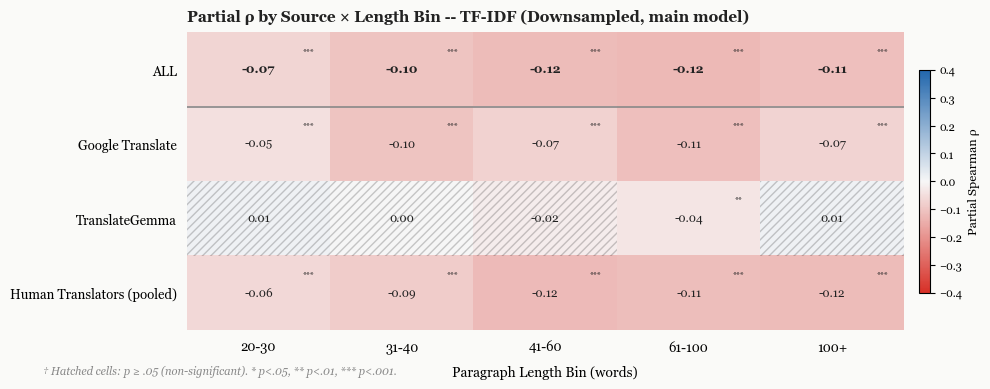

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#fafaf8")

row_labels = ["ALL", "gt", "gemma", "human_translation"]
n_rows, n_cols = len(row_labels), len(binLabels)
rho_matrix = np.full((n_rows, n_cols), np.nan)
p_matrix = np.full((n_rows, n_cols), np.nan)
n_matrix = np.full((n_rows, n_cols), np.nan)

for i, src in enumerate(row_labels):
    for j, bin_lbl in enumerate(binLabels):
        row = len_df[(len_df["para_source"] == src) & (len_df["length_bin"] == bin_lbl)]
        if not row.empty:
            rho_matrix[i, j] = row["partial_spearman_r"].values[0]
            p_matrix[i, j] = row["p_value"].values[0]
            n_matrix[i, j] = row["n"].values[0]

cmap = LinearSegmentedColormap.from_list("rho_cmap", ["#d73027", "#f7f7f7", "#2166ac"])
im = ax.imshow(rho_matrix, cmap=cmap, vmin=-0.4, vmax=0.4, aspect="auto", zorder=1)

for i in range(n_rows):
    for j in range(n_cols):
        if not np.isnan(p_matrix[i, j]) and p_matrix[i, j] >= 0.05:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch="////", edgecolor=(0, 0, 0, 0.2), linewidth=0, zorder=2))

for i in range(n_rows):
    for j in range(n_cols):
        if np.isnan(rho_matrix[i, j]):
            continue
        txt_color = "white" if abs(rho_matrix[i, j]) > 0.2 else "#222"
        ax.text(j, i, f"{rho_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9 if row_labels[i] == "ALL" else 8.5, fontweight="bold" if row_labels[i] == "ALL" else "normal", color=txt_color, zorder=3)
        stars = sig_stars(p_matrix[i, j])
        if stars != "ns":
            ax.text(j + 0.35, i - 0.25, stars, ha="center", va="center", fontsize=6, color=txt_color, zorder=3)

ax.axhline(0.5, color="#888", linewidth=1.2, zorder=4)
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(binLabels, fontsize=9.5)
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(["ALL", translationSourceLabels["gt"], translationSourceLabels["gemma"], translationSourceLabels["human_translation"]], fontsize=9.5)
ax.tick_params(left=False, bottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlabel("Paragraph Length Bin (words)", fontsize=10, labelpad=8)
ax.set_title("Partial ρ by Source × Length Bin -- TF-IDF (Downsampled, main model)", fontsize=11, fontweight="bold", loc="left", pad=8, color="#222")

cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.015, pad=0.02, shrink=0.85)
cbar.set_label("Partial Spearman ρ", fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax.text(-0.2, -0.15, "† Hatched cells: p ≥ .05 (non-significant). * p<.05, ** p<.01, *** p<.001.", transform=ax.transAxes, fontsize=8, color="#888", style="italic")

plt.tight_layout()
#plt.savefig("panel_c_heatmap_pooledHT_downsamp.png", dpi=200, bbox_inches="tight", facecolor="#fafaf8")
plt.show()

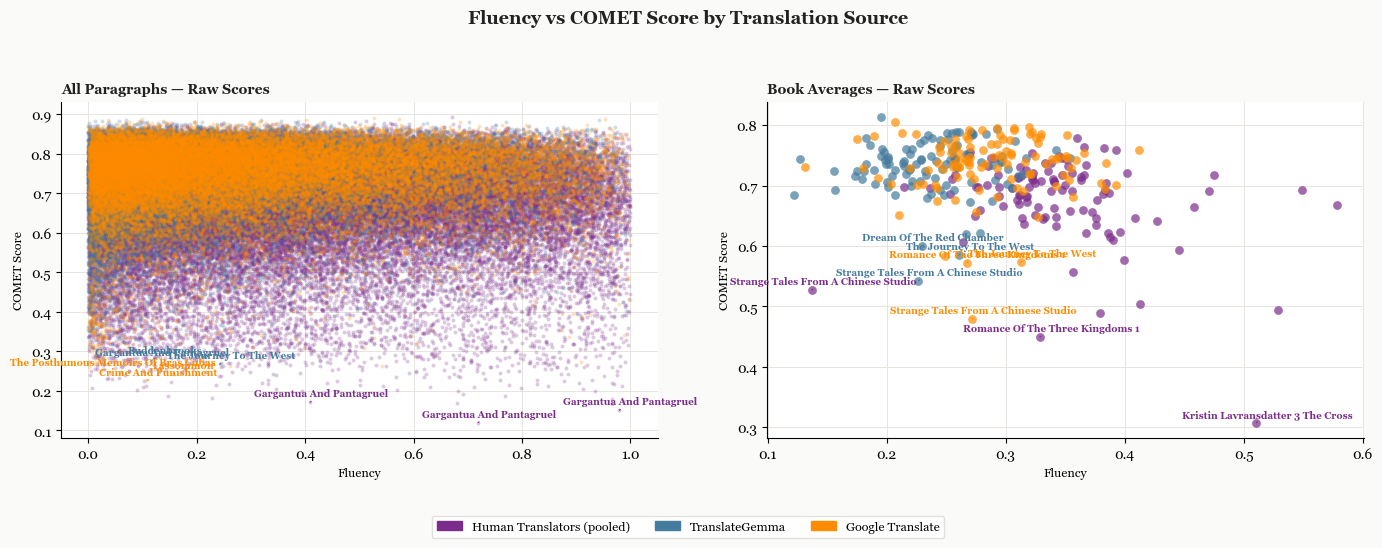

In [14]:
meta = pd.read_csv(metadataCSV)
meta["book_id"] = meta["Book_id"].astype(str)
book_title = meta.set_index("book_id")["Title"].to_dict()

grouping_colors = {"human": "#7b2d8b", "gemma": "#457b9d", "gt": "darkorange"}
grouping_labels = {"human": "Human Translators (pooled)", "gemma": "TranslateGemma", "gt": "Google Translate"}

plot_df = valid.copy()
plot_df["group"] = plot_df["para_source"].apply(assign_group)
plot_df = plot_df.dropna(subset=["group", "fluency", "comet_score", "paragraph_len"])

book_df = (
    plot_df.groupby(["book_id", "group"])[["fluency", "comet_score", "paragraph_len"]]
    .mean()
    .reset_index()
)


def plot_panel(ax, df, x_col, y_col, title, xlabel, ylabel, point_size, alpha, n_outliers=3):
    for grp, color in grouping_colors.items():
        sub = df[df["group"] == grp].dropna(subset=[x_col, y_col])
        x = sub[x_col].values
        y = sub[y_col].values
        ax.scatter(x, y, color=color, alpha=alpha, s=point_size, linewidths=0, label=grouping_labels[grp], rasterized=True)
        if len(x) > 5 and "book_id" in sub.columns and n_outliers > 0:
            m, b = np.polyfit(x, y, 1)
            residuals = np.abs(y - (m * x + b))
            for _, row in sub.iloc[np.argsort(residuals)[-n_outliers:]].iterrows():
                bid = str(row["book_id"])
                ax.annotate(book_title.get(bid, bid), xy=(row[x_col], row[y_col]), xytext=(8, 4), textcoords="offset points", fontsize=7, color=color, fontweight="bold", ha="center", arrowprops=dict(arrowstyle="-", color=color, lw=0.8))
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left", color="#222")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("#ffffff")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#fafaf8")
fig.suptitle("Fluency vs COMET Score by Translation Source", fontsize=13, fontweight="bold", y=1.02, color="#222")

plot_panel(axes[0], plot_df, "fluency", "comet_score", "All Paragraphs — Raw Scores", "Fluency", "COMET Score", 8, 0.25, n_outliers=3)
plot_panel(axes[1], book_df, "fluency", "comet_score", "Book Averages — Raw Scores", "Fluency", "COMET Score", 40, 0.7)

legend_handles = [mpatches.Patch(color=grouping_colors[g], label=grouping_labels[g]) for g in grouping_colors]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9, frameon=True, framealpha=0.9, edgecolor="#ddd", bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
#plt.savefig("score_space_raw_downsamp_horiz.png", dpi=200, bbox_inches="tight", facecolor="#fafaf8")
plt.show()